# Challenge 10 - data fitting with polynomials

generating polynomials to help up predict data!

steps:
1. Select Degree: Choose the degree of the polynomial based on the complexity of the data. Higher degrees allow more flexibility but may lead to overfitting.
2. Fit the Polynomial: Use a least-squares method to compute the coefficients a 0,a 1,…,a n of the polynomial that minimizes the error between predicted and actual values.
3. Evaluate the Fit: Calculate error metrics such as Mean Squared Error (MSE) or R-squared to assess how well the model fits the data.


Rules:
- start with a low degree - start with 1-3 then increase if error too big
- keep the degree smaller than number of points - 1 -> too accurate wont be any help for predicting
- concider physics and know where the data is coming from
- if tou need degree 10, try something else

In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt


# Step 1: Generate some sample data
# Creating data points that roughly follow a quadratic curve

np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise


In [2]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 15 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients) 


# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
#this creates a function based on the coeefients we generated


Polynomial Coefficients:  [-1.74771266e-06  9.38973299e-07  1.61353605e-04 -3.96195404e-05
 -5.97939499e-03 -3.17802055e-04  1.13849286e-01  3.83010603e-02
 -1.18388915e+00 -6.63600408e-01  6.58472724e+00  4.30302606e+00
 -1.76197496e+01 -7.33866097e+00  1.85416072e+01  4.11389585e+00]


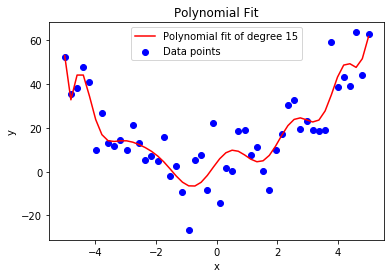

In [3]:
# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x)

# Step 4: Plotting the results
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')

# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### evaluating the fit!

- MSE - quantifing the error - low means the prection is close to actual values
- R squared - inution of how well the model is representing if the model is foing a good job represnting the relationship!

both of these should be used togetehr to get a understanding

MSE - how far off, R suared how well the models reps the overall trend

In [4]:
# Mean Squared Error (MSE)
mse = np.mean((y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')
# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')


Mean Squared Error: 86.1701
R-squared: 0.7812


what do these values mean?

MSE -
    - low = better fit
    - high - poor fit
    
R^2 - if too high try something else!
   -  =1 -> explains 100% of the varience
   -  =0 -> explains none of the variblility
   -  <0 (negitive) -> worse than using the mean, very poor model

over fitting 
- degree poly too high -> the curve is fitting the noise so there is no generalization
    - oscillations, residuals look random, tiny changes in data creates big changes in poly
    
Under fitting
- degree to low the model fails to capture the data completely
    - curce missed obviouse curviture, large residual, systematic error patterns

# part A

In [5]:
import random

rng = np.random.default_rng(seed=42)

X = rng.uniform(5, 10, size=5)   # 5 floats in [5, 10)
X.sort()                         # optional: sort them
Y = rng.uniform(5, 10, size=5)   # 5 floats in [5, 10)

# Stack the design matrix with a column of ones (for the intercept) 
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

ysol = m*X + c



Slope: -0.8210686408723734, Intercept: 14.557370412751427


Polynomial Coefficients:  [ 0.01529166 -0.48966706  3.85082732  0.94082544]


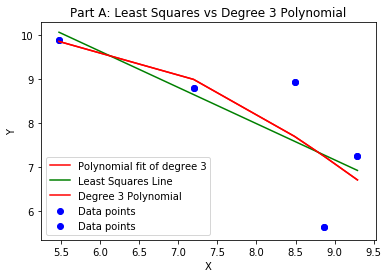

In [6]:
#polyfit

degree = 3
coefficients = np.polyfit(X, Y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(X)

print("Polynomial Coefficients: ", coefficients)

plt.scatter(X, Y, color='blue', label='Data points') # Original data points
plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')


plt.scatter(X, Y, color='blue', label='Data points')
plt.plot(X, ysol, color='green', label='Least Squares Line')
plt.plot(X, y_pred, color='red', label='Degree 3 Polynomial')
plt.xlabel('X')
plt.ylabel('Y')
plt.title("Part A: Least Squares vs Degree 3 Polynomial")
plt.legend()
plt.show()

In [7]:
#evaluating the results!!
def evaluate(Y, y_pred):
    mse = np.mean((Y - y_pred)**2)
    print(f'Mean Squared Error: {mse:.4f}')

    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    print(f'R-squared: {r_squared:.4f}')
    return mse, r_squared

print("Least Squares Results:")
mse_ls, r2_ls = evaluate(Y, ysol)
print()
print("Polynomial Degree 3 Results:")
mse_poly, r2_poly = evaluate(Y, y_pred)

if (mse_poly < mse_ls) and (r2_poly > r2_ls):
    print(" degree 3 polynomial is etter")
elif (mse_ls < mse_poly) and (r2_ls > r2_poly):
    print("least squares line is the better")
else:
    print("The results are mixed")

Least Squares Results:
Mean Squared Error: 0.9268
R-squared: 0.5832

Polynomial Degree 3 Results:
Mean Squared Error: 0.8823
R-squared: 0.6032
 degree 3 polynomial is etter


# part b

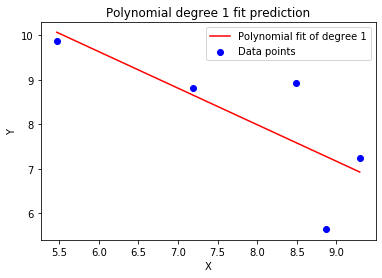

Mean Squared Error: 0.9268
R-squared: 0.5832
underfitting because the model is too simple.



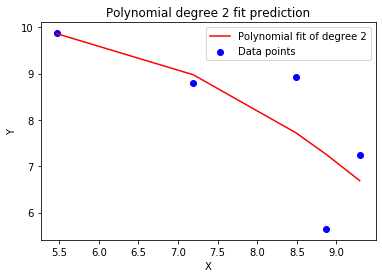

Mean Squared Error: 0.8826
R-squared: 0.6030
 reasonable fit.



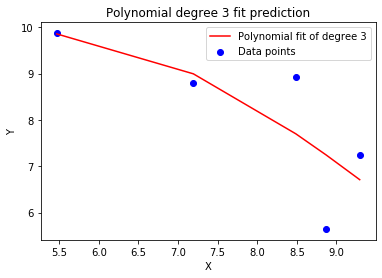

Mean Squared Error: 0.8823
R-squared: 0.6032
 reasonable fit.



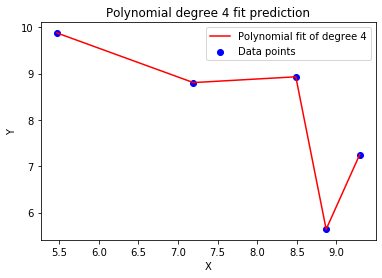

Mean Squared Error: 0.0000
R-squared: 1.0000
overfitting because degree 4 = n-1 for 5 data points.



In [8]:

def polyDeg(X,Y,degree):
    coefficients = np.polyfit(X, Y, degree)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(X)

    plt.scatter(X, Y, color='blue', label='Data points')
    plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Polynomial degree {degree} fit prediction')
    plt.legend()
    plt.show()

    evaluate(Y, y_pred)

for degree in range(1, 5):
    polyDeg(X, Y, degree)
    
    if degree == 1:
        print("underfitting because the model is too simple.")
    elif degree == 4:
        print("overfitting because degree 4 = n-1 for 5 data points.")
    else:
        print(" reasonable fit.")
    print()

## part C

[[  1.           5.47088674  29.93060172 163.74693203]
 [  1.           7.1943922   51.75927911 372.37655384]
 [  1.           8.48684015  72.02645565 611.27701535]
 [  1.           8.86978024  78.67300156 697.81223483]
 [  1.           9.2929896   86.3596557  802.53938222]]
Vandermonde Coefficients:  [ 0.94082544  3.85082732 -0.48966706  0.01529166]


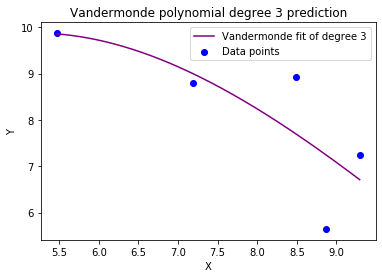

Vandermonde degree 3
Mean Squared Error: 0.8823
R-squared: 0.6032


(0.8823007948513407, 0.6031801378020638)

In [9]:


degree = 3

def create_vandermonde_matrix(X, degree):
    V = np.vander(X, N=degree+1, increasing=True)
    return V

V = create_vandermonde_matrix(X, degree)
print(V)

#solve for coefficients
VT_V = np.dot(V.T, V)
VT_Y = np.dot(V.T, Y)
coefficients = np.linalg.solve(VT_V, VT_Y)
print("Vandermonde Coefficients: ", coefficients)

# predicted y values on the original x values
y_pred = np.dot(V, coefficients)

x_fit = np.linspace(np.min(X), np.max(X), 200)
V_fit = create_vandermonde_matrix(x_fit, degree)
y_fit = np.dot(V_fit, coefficients)

#plot
plt.scatter(X, Y, color='blue', label='Data points')
plt.plot(x_fit, y_fit, color='purple', label=f'Vandermonde fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.title("Vandermonde polynomial degree 3 prediction")
plt.legend()
plt.show()

print("Vandermonde degree 3")
evaluate(Y, y_pred)